In [5]:
import pandas as pd
#  All numerical (classical)
df_all = pd.read_csv("MRI_All_Numerical_Features.xls")
# Quantum features (QFT + QWT patches)
df_quantum = pd.read_csv("MRI_Quantum_QFT_QWT_Patch_Features.xls")
# Classical + Quantum fused features
df_fused = pd.read_csv("MRI_Classical_Quantum_Fused_Features.xls")
# Print shapes
print("All Numerical Shape:", df_all.shape)
print("Quantum Features Shape:", df_quantum.shape)
print("Fused Features Shape:", df_fused.shape)


All Numerical Shape: (8763, 101)
Quantum Features Shape: (8763, 33)
Fused Features Shape: (8763, 133)


In [6]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler

# Load datasets
df_all = pd.read_csv("MRI_All_Numerical_Features.xls")
df_quantum = pd.read_csv("MRI_Quantum_QFT_QWT_Patch_Features.xls")
df_fused = pd.read_csv("MRI_Classical_Quantum_Fused_Features.xls")

datasets = [df_all, df_quantum, df_fused]
names = ["All Numerical", "Quantum Features", "Fused Features"]

balanced_dfs = []

# Oversample each dataset
ros = RandomOverSampler(random_state=42)

for df, name in zip(datasets, names):
    print(f"\n{name} Before Oversampling:")
    print(df['label'].value_counts())
    
    # Split features and label
    X = df.drop('label', axis=1)
    y = df['label']
    
    # Apply RandomOverSampler
    X_res, y_res = ros.fit_resample(X, y)
    
    # Combine back into DataFrame
    df_balanced = pd.DataFrame(X_res, columns=X.columns)
    df_balanced['label'] = y_res
    balanced_dfs.append(df_balanced)
    
    print(f"{name} After Oversampling:")
    print(df_balanced['label'].value_counts())



All Numerical Before Oversampling:
label
0    6621
1    2142
Name: count, dtype: int64
All Numerical After Oversampling:
label
1    6621
0    6621
Name: count, dtype: int64

Quantum Features Before Oversampling:
label
0    6621
1    2142
Name: count, dtype: int64
Quantum Features After Oversampling:
label
1    6621
0    6621
Name: count, dtype: int64

Fused Features Before Oversampling:
label
0    6621
1    2142
Name: count, dtype: int64
Fused Features After Oversampling:
label
1    6621
0    6621
Name: count, dtype: int64


In [7]:
# Shuffle the balanced datasets
for i in range(len(balanced_dfs)):
    balanced_dfs[i] = balanced_dfs[i].sample(frac=1, random_state=42).reset_index(drop=True)
# Save to CSV
balanced_dfs[0].to_csv("C.csv", index=False)   # All Numerical
balanced_dfs[1].to_csv("Q.csv", index=False)   # Quantum Features
balanced_dfs[2].to_csv("QC.csv", index=False)  # Fused Features
print("Balanced datasets shuffled and saved successfully as C.csv, Q.csv, and QC.csv")


Balanced datasets shuffled and saved successfully as C.csv, Q.csv, and QC.csv


In [8]:
import pandas as pd
# Load the saved CSV files
df_C = pd.read_csv("C.csv")
df_Q = pd.read_csv("Q.csv")
df_QC = pd.read_csv("QC.csv")
# Print label counts
datasets = [df_C, df_Q, df_QC]
names = ["All Numerical (C.csv)", "Quantum Features (Q.csv)", "Fused Features (QC.csv)"]
for df, name in zip(datasets, names):
    print(f"\n{name} Label Counts:")
    print(df['label'].value_counts())



All Numerical (C.csv) Label Counts:
label
1    6621
0    6621
Name: count, dtype: int64

Quantum Features (Q.csv) Label Counts:
label
1    6621
0    6621
Name: count, dtype: int64

Fused Features (QC.csv) Label Counts:
label
1    6621
0    6621
Name: count, dtype: int64


In [9]:
import pandas as pd
C_clean = pd.read_csv("C_clean.csv")
Q_clean = pd.read_csv("Q_clean.csv")
QC_clean = pd.read_csv("QC_clean.csv")
print("C_clean shape:", C_clean.shape)
print("Q_clean shape:", Q_clean.shape)
print("QC_clean shape:", QC_clean.shape)


C_clean shape: (13242, 44)
Q_clean shape: (13242, 31)
QC_clean shape: (13242, 74)


In [10]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        "Train_Time_sec": train_time,
        "CM": confusion_matrix(y_test, y_pred),
        "ROC": roc_curve(y_test, y_prob) if y_prob is not None else None
    }
    
    return metrics


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Only QC dataset
datasets = {
    "QC": QC_clean
}

# Models to train
models = {
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "RF": RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42
    ),
    "GB": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}


In [12]:
results = {}

for dname, df in datasets.items():
    X = df.drop(columns=["label"])
    y = df["label"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    for mname, model in models.items():
        key = f"{mname}_{dname}"
        results[key] = train_and_evaluate(
            model, X_train, X_test, y_train, y_test
        )


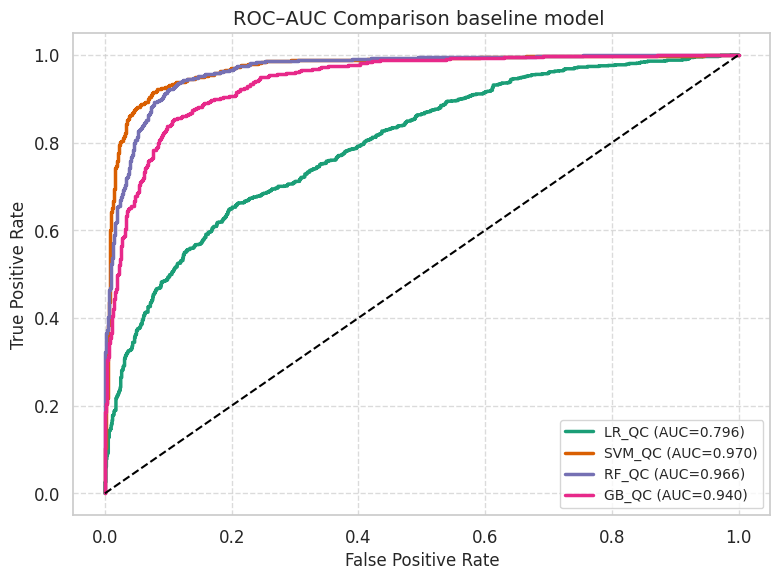

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.set(style="whitegrid", font_scale=1.1)

# Filter and plot only QC models
qc_results = {k: v for k, v in results.items() if "" in k}

# Print-quality high-contrast colors
colors = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]  # Green, Orange, Purple, Pink

for i, (key, res) in enumerate(qc_results.items()):
    if res.get("ROC") is not None:
        fpr, tpr, _ = res["ROC"]
        plt.plot(
            fpr, tpr,
            label=f"{key} (AUC={res['AUC']:.3f})",
            linewidth=2.5,
            color=colors[i % len(colors)]
        )

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5)

# Labels and title
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC–AUC Comparison baseline model ", fontsize=14)

# Legend
plt.legend(fontsize=10, loc="lower right", frameon=True)

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save figure for journal (high resolution)
plt.savefig("ROC_AUC_QC_Comparison_Print.png", dpi=600)

plt.show()


In [14]:
import time
import numpy as np

# Example: measure time for QC models
X_sample = QC_clean.drop(columns=["label"]).values
y_sample = QC_clean["label"].values

for name, model in models.items():
    # Fit model first (if not already trained)
    model.fit(X_sample, y_sample)
    
    # Measure inference time
    start = time.time()
    y_pred = model.predict(X_sample)
    end = time.time()
    
    elapsed_time = end - start  # in seconds
    avg_time_per_sample = elapsed_time / X_sample.shape[0]
    
    print(f"{name}: Total inference time = {elapsed_time:.4f}s, Per sample = {avg_time_per_sample*1000:.4f} ms")


LR: Total inference time = 0.0355s, Per sample = 0.0027 ms
SVM: Total inference time = 17.1007s, Per sample = 1.2914 ms
RF: Total inference time = 0.2215s, Per sample = 0.0167 ms
GB: Total inference time = 0.0680s, Per sample = 0.0051 ms


In [ ]:
import psutil
import os

# Function to measure CPU usage during model inference
def measure_cpu(model, X):
    process = psutil.Process(os.getpid())
    cpu_before = psutil.cpu_percent(interval=None)
    time_start = time.time()
    
    y_pred = model.predict(X)
    
    time_end = time.time()
    cpu_after = psutil.cpu_percent(interval=None)
    
    elapsed_time = time_end - time_start
    cpu_usage = cpu_after - cpu_before
    
    return elapsed_time, cpu_usage

for name, model in models.items():
    elapsed, cpu = measure_cpu(model, X_sample)
    print(f"{name}: Inference time = {elapsed:.4f}s, CPU usage = {cpu:.2f}%")


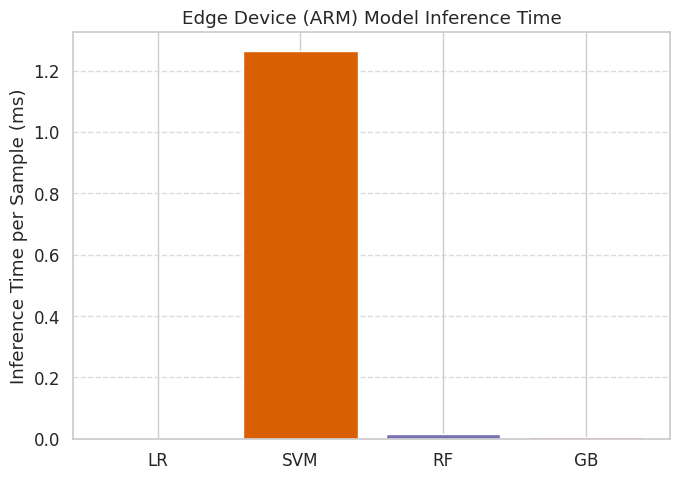

In [15]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Features and labels
X_sample = QC_clean.drop(columns=["label"]).values
y_sample = QC_clean["label"].values

# Dictionary to store runtimes
runtime_per_model = {}

# Run models and measure inference time
for name, model in models.items():
    # Fit the model (if not already trained)
    model.fit(X_sample, y_sample)
    
    # Measure inference time
    start = time.time()
    y_pred = model.predict(X_sample)
    end = time.time()
    
    elapsed_time = end - start
    runtime_per_model[name] = elapsed_time / X_sample.shape[0]  # per sample

# Prepare data for plotting
models_list = list(runtime_per_model.keys())
runtime_ms = [runtime_per_model[m]*1000 for m in models_list]  # convert to ms

# Plot
plt.figure(figsize=(7,5))
plt.bar(models_list, runtime_ms, color=["#1b9e77","#d95f02","#7570b3","#e7298a"])
plt.ylabel("Inference Time per Sample (ms)")
plt.title("Edge Device (ARM) Model Inference Time")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [16]:
import psutil
import matplotlib.pyplot as plt
import time
import subprocess

# Number of seconds to monitor
duration = 60
interval = 1  # seconds

# Lists to store measurements
timestamps = []
cpu_usage = []
ram_usage = []
net_sent = []
net_recv = []
temp_cpu = []

# Get initial network stats
net_io_start = psutil.net_io_counters()

print("Monitoring started...")

for i in range(0, duration, interval):
    timestamps.append(i)

    # CPU usage %
    cpu_usage.append(psutil.cpu_percent(interval=None))

    # RAM usage %
    ram = psutil.virtual_memory()
    ram_usage.append(ram.percent)

    # Network usage (bytes sent/recv since start)
    net_io = psutil.net_io_counters()
    net_sent.append((net_io.bytes_sent - net_io_start.bytes_sent)/1024)  # KB
    net_recv.append((net_io.bytes_recv - net_io_start.bytes_recv)/1024)  # KB

    # CPU temperature
    try:
        temp = float(subprocess.check_output(
            ["vcgencmd", "measure_temp"]
        ).decode().split('=')[1].split("'")[0])
    except:
        temp = 0.0
    temp_cpu.append(temp)

    time.sleep(interval)

print("Monitoring finished.")


Monitoring started...
Monitoring finished.


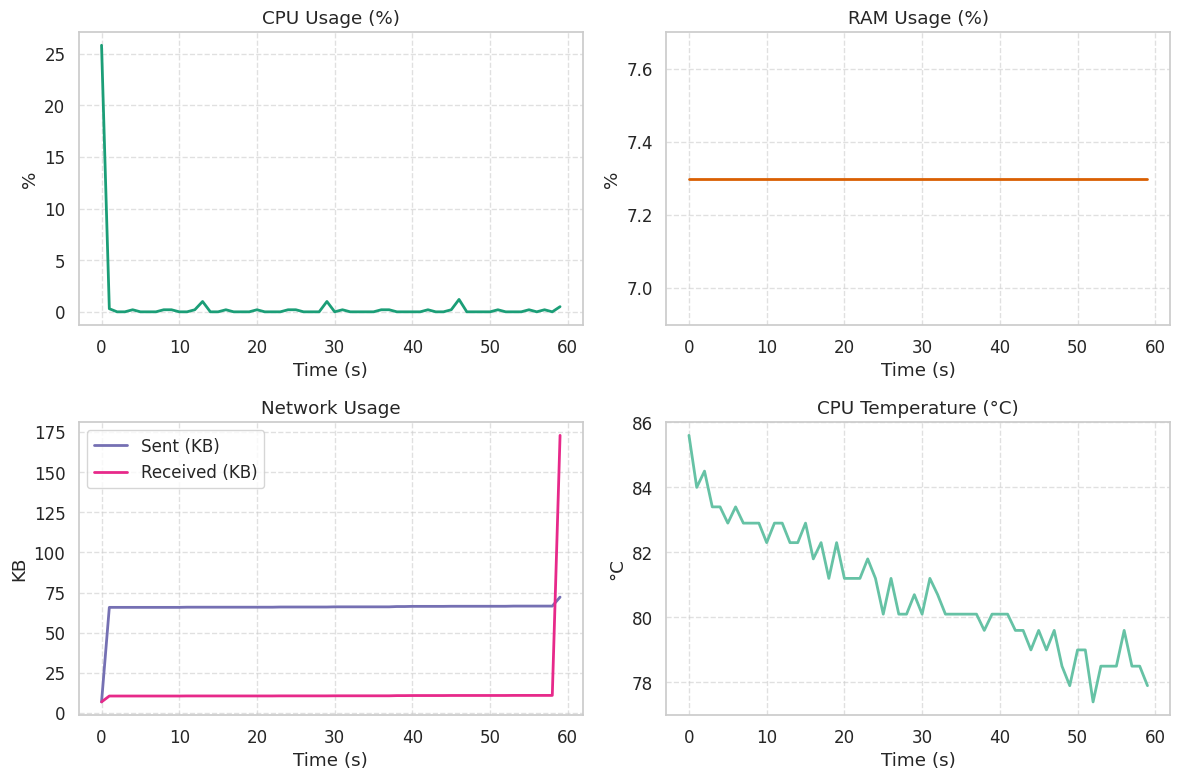

In [17]:
plt.figure(figsize=(12, 8))

# CPU Usage
plt.subplot(2,2,1)
plt.plot(timestamps, cpu_usage, color="#1b9e77", linewidth=2)
plt.title("CPU Usage (%)")
plt.xlabel("Time (s)")
plt.ylabel("%")
plt.grid(True, linestyle='--', alpha=0.6)

# RAM Usage
plt.subplot(2,2,2)
plt.plot(timestamps, ram_usage, color="#d95f02", linewidth=2)
plt.title("RAM Usage (%)")
plt.xlabel("Time (s)")
plt.ylabel("%")
plt.grid(True, linestyle='--', alpha=0.6)

# Network Usage
plt.subplot(2,2,3)
plt.plot(timestamps, net_sent, label="Sent (KB)", color="#7570b3", linewidth=2)
plt.plot(timestamps, net_recv, label="Received (KB)", color="#e7298a", linewidth=2)
plt.title("Network Usage")
plt.xlabel("Time (s)")
plt.ylabel("KB")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# CPU Temperature
plt.subplot(2,2,4)
plt.plot(timestamps, temp_cpu, color="#66c2a5", linewidth=2)
plt.title("CPU Temperature (°C)")
plt.xlabel("Time (s)")
plt.ylabel("°C")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [18]:
# ------------------------ QFFMLNet class ------------------------
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

class QFFMLNet:
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.smote = SMOTE(random_state=self.random_state)

        self.rf = RandomForestClassifier(random_state=self.random_state)
        self.gb = GradientBoostingClassifier(random_state=self.random_state)
        self.lr = LogisticRegression(max_iter=1000, random_state=self.random_state)
        self.svc = SVC(probability=True, random_state=self.random_state)

        self.best_rf = None
        self.best_gb = None
        self.best_lr = None
        self.best_svc = None
        self.ensemble = None

    def create_pipeline(self, clf):
        return ImbPipeline([
            ('smote', self.smote),
            ('scaler', self.scaler),
            ('clf', clf)
        ])

    def tune_models(self, X_train, y_train):
        param_grid_rf = {
            'clf__n_estimators': [100, 300, 500],
            'clf__max_depth': [None, 10, 20],
            'clf__min_samples_split': [2, 5, 10],
        }
        param_grid_gb = {
            'clf__n_estimators': [100, 200],
            'clf__learning_rate': [0.05, 0.1, 0.2],
            'clf__max_depth': [3, 5, 7],
        }
        param_grid_lr = {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l2'],
            'clf__solver': ['lbfgs'],
        }
        param_grid_svc = {
            'clf__C': [0.1, 1, 10],
            'clf__gamma': ['scale', 'auto'],
            'clf__kernel': ['rbf', 'linear'],
        }

        pipe_rf = self.create_pipeline(self.rf)
        pipe_gb = self.create_pipeline(self.gb)
        pipe_lr = self.create_pipeline(self.lr)
        pipe_svc = self.create_pipeline(self.svc)

        rs_rf = RandomizedSearchCV(pipe_rf, param_grid_rf, n_iter=10, cv=3, scoring='roc_auc', n_jobs=-1, random_state=self.random_state)
        rs_gb = RandomizedSearchCV(pipe_gb, param_grid_gb, n_iter=10, cv=3, scoring='roc_auc', n_jobs=-1, random_state=self.random_state)
        rs_lr = RandomizedSearchCV(pipe_lr, param_grid_lr, n_iter=8, cv=3, scoring='roc_auc', n_jobs=-1, random_state=self.random_state)
        rs_svc = RandomizedSearchCV(pipe_svc, param_grid_svc, n_iter=8, cv=3, scoring='roc_auc', n_jobs=-1, random_state=self.random_state)

        print("Tuning Random Forest...")
        rs_rf.fit(X_train, y_train)
        self.best_rf = rs_rf.best_estimator_

        print("Tuning Gradient Boosting...")
        rs_gb.fit(X_train, y_train)
        self.best_gb = rs_gb.best_estimator_

        print("Tuning Logistic Regression...")
        rs_lr.fit(X_train, y_train)
        self.best_lr = rs_lr.best_estimator_

        print("Tuning SVC...")
        rs_svc.fit(X_train, y_train)
        self.best_svc = rs_svc.best_estimator_

    def train_ensemble(self, X_train, y_train):
        clf_rf = self.best_rf.named_steps['clf']
        clf_gb = self.best_gb.named_steps['clf']
        clf_lr = self.best_lr.named_steps['clf']
        clf_svc = self.best_svc.named_steps['clf']

        self.ensemble = VotingClassifier(
            estimators=[
                ('rf', clf_rf),
                ('gb', clf_gb),
                ('lr', clf_lr),
                ('svc', clf_svc)
            ],
            voting='soft',
            n_jobs=-1
        )

        X_train_scaled = self.scaler.fit_transform(X_train)
        X_train_res, y_train_res = self.smote.fit_resample(X_train_scaled, y_train)
        self.ensemble.fit(X_train_res, y_train_res)

    def evaluate(self, X_test, y_test):
        X_test_scaled = self.scaler.transform(X_test)
        y_pred = self.ensemble.predict(X_test_scaled)
        y_proba = self.ensemble.predict_proba(X_test_scaled)[:, 1]

        print("HQCE Net")
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title("HQCE Net Confusion Matrix")
        plt.show()

        auc_score = roc_auc_score(y_test, y_proba)
        fpr, tpr, _ = roc_curve(y_test, y_proba)

        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f"QFF-ML Net (AUC = {auc_score:.3f})")
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("HQCE Net ROC Curve")
        plt.legend()
        plt.grid(alpha=0.5)
        plt.show()
